# Task 2: Customer Churn Prediction — End-to-End ML Pipeline

## What are we building?

A telecom company wants to know: **which customers are likely to cancel their subscription?**

If they can predict this before it happens, they can reach out with a discount or a better plan and potentially keep the customer. This is called **churn prediction** and it's one of the most common real-world ML problems.

The focus of this task isn't just building a model — it's building a **pipeline**. A pipeline bundles all your preprocessing steps + model into one object that you can save, reload, and use on new data without re-running anything. This is how real ML systems work in production.

## Dataset
The **Telco Customer Churn** dataset — 7,043 customers with their subscription details, services they use, and whether they churned (Yes/No). Available on Kaggle.

## Plan
1. Load and explore the data
2. Clean it up
3. Build a proper sklearn Pipeline
4. Train Logistic Regression and Random Forest
5. Tune hyperparameters with GridSearchCV
6. Evaluate and compare models
7. Export the final pipeline with joblib
8. Show how to use the saved pipeline on new data

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# sklearn — the core tools
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
BLUE, RED, GREEN, ORANGE, PURPLE = '#2196F3','#e74c3c','#27ae60','#FF6B35','#9C27B0'

print('all imports ready')

all imports ready


---
## Step 1 — Loading the Data

In [2]:
# Load the Telco Churn dataset
# Download from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

df = pd.read_csv('telco_churn.csv')
print('Shape:', df.shape)
print(f'Customers: {len(df):,}')
df.head()

Shape: (7043, 20)
Customers: 7,043


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,No,66,Yes,No,Fiber optic,No internet service,No internet service,No internet service,No,No internet service,Yes,One year,No,Electronic check,99.10,6557.39,No
1,Female,1,No,No,24,Yes,No,Fiber optic,Yes,No,No,No internet service,No,No internet service,Two year,No,Credit card (automatic),113.02,2686.82,No
2,Male,0,No,No,60,Yes,No,Fiber optic,No internet service,No,No,No,Yes,No,Month-to-month,Yes,Mailed check,51.93,3102.86,No
3,Male,0,Yes,No,25,Yes,No,DSL,No,No,Yes,No,No internet service,Yes,Month-to-month,Yes,Electronic check,81.21,2038.61,No
4,Male,0,Yes,No,33,Yes,Yes,DSL,Yes,Yes,No,No,No,Yes,One year,Yes,Bank transfer (automatic),40.85,1351.63,No


In [3]:
print('Column names:')
print(df.columns.tolist())
print()
df.info()

Column names:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProt

In [4]:
df.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7032.00
mean,0.15,35.82,67.90,2442.03
std,0.36,20.73,28.99,1863.62
min,0.00,0.00,18.06,0.00
25%,0.00,18.00,42.40,953.33
50%,0.00,36.00,68.34,1981.36
75%,0.00,54.00,93.16,3620.59
max,1.00,71.00,117.98,8341.70


---
## Step 2 — Quick EDA (Understanding the data before touching it)

Before building anything, I want to understand: who churns? What do churned customers look like compared to those who stayed?

### How many customers actually churned?

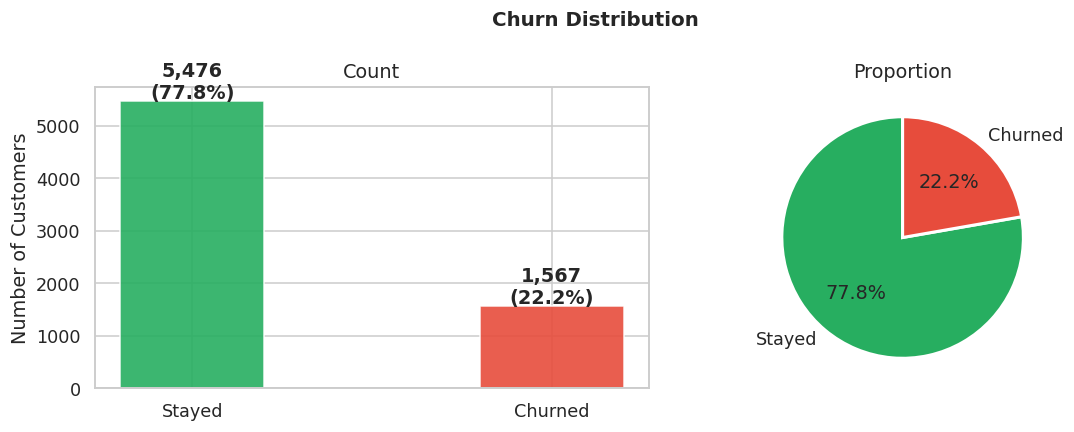

Churn rate: 22.2%
This is a class imbalance — the model will see far more "Stayed" examples.
We will handle this with class_weight="balanced" in our models.


In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Churn Distribution', fontsize=13, fontweight='bold')

axes[0].bar(['Stayed', 'Churned'], churn_counts.values,
            color=[GREEN, RED], edgecolor='white', alpha=0.9, width=0.4)
for i, (v, p) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, v + 50, f'{v:,}\n({p:.1f}%)', ha='center', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Count')

axes[1].pie(churn_counts.values, labels=['Stayed','Churned'],
            colors=[GREEN, RED], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('churn_distribution.png', bbox_inches='tight')
plt.show()

print(f'Churn rate: {churn_pct["Yes"]:.1f}%')
print('This is a class imbalance — the model will see far more "Stayed" examples.')
print('We will handle this with class_weight="balanced" in our models.')

### Tenure, Monthly Charges and Contract — the three biggest predictors

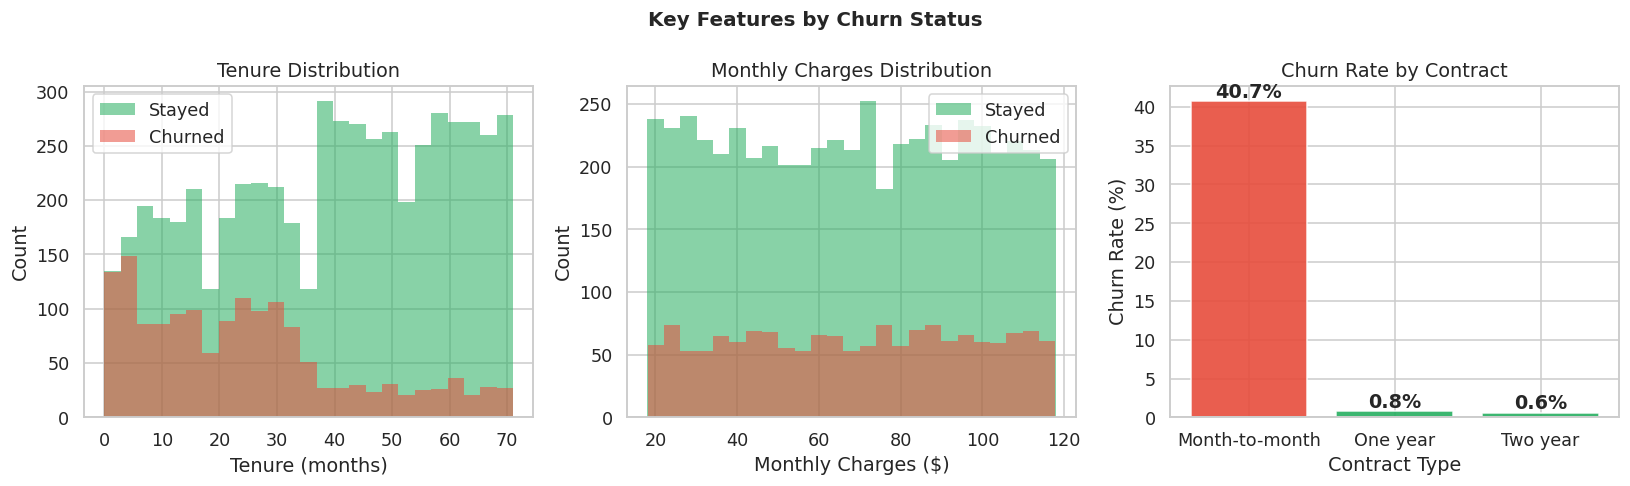

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Key Features by Churn Status', fontsize=13, fontweight='bold')

palette = {'No': GREEN, 'Yes': RED}

# Tenure — longer customers churn less
for churn_val, color, label in [('No', GREEN, 'Stayed'), ('Yes', RED, 'Churned')]:
    data = df[df['Churn'] == churn_val]['tenure']
    axes[0].hist(data, bins=25, alpha=0.55, color=color, label=label, edgecolor='none')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].set_title('Tenure Distribution')
axes[0].legend()

# Monthly charges
for churn_val, color, label in [('No', GREEN, 'Stayed'), ('Yes', RED, 'Churned')]:
    data = df[df['Churn'] == churn_val]['MonthlyCharges']
    axes[1].hist(data, bins=25, alpha=0.55, color=color, label=label, edgecolor='none')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Monthly Charges Distribution')
axes[1].legend()

# Contract type — month-to-month customers churn way more
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)

bar_colors = [RED if v > 30 else ORANGE if v > 10 else GREEN
              for v in contract_churn.values]
axes[2].bar(contract_churn.index, contract_churn.values,
            color=bar_colors, edgecolor='white', alpha=0.9)
for i, v in enumerate(contract_churn.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[2].set_xlabel('Contract Type')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_title('Churn Rate by Contract')

plt.tight_layout()
plt.savefig('key_features.png', bbox_inches='tight')
plt.show()

Three things jump out already:
- **New customers churn way more** — if someone's been with you for 3+ years, they rarely leave
- **Higher monthly charges = higher churn** — customers paying more feel the pain more
- **Month-to-month contracts = highest churn** — no commitment, easy to leave

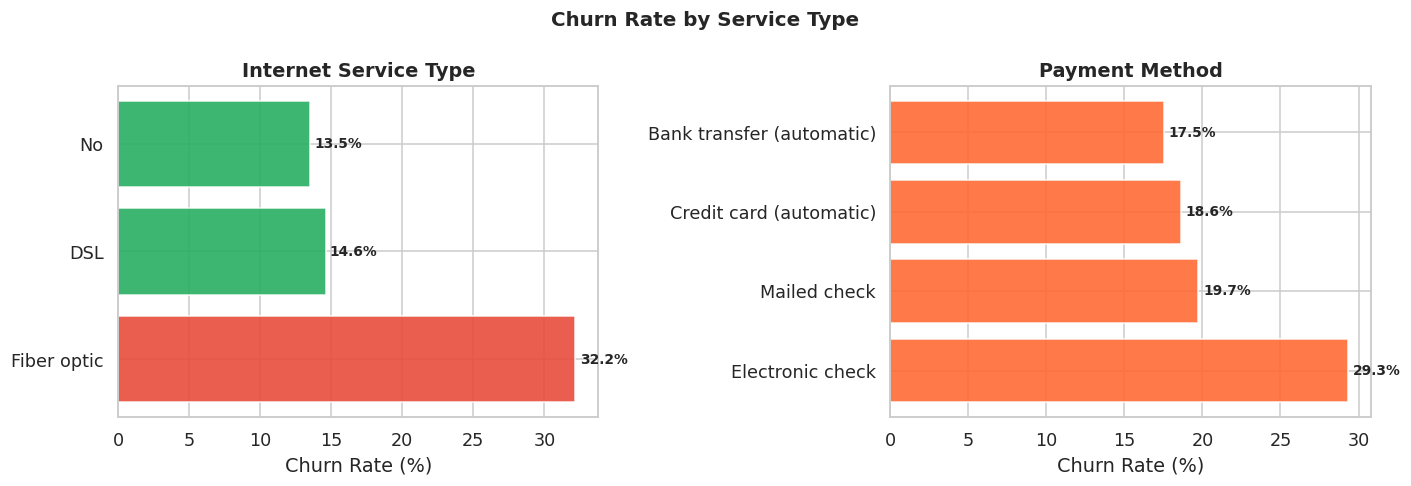

In [7]:
# Churn rate by internet service and payment method
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Churn Rate by Service Type', fontsize=13, fontweight='bold')

for ax, col, title in [
    (axes[0], 'InternetService',  'Internet Service Type'),
    (axes[1], 'PaymentMethod',    'Payment Method'),
]:
    rates = df.groupby(col)['Churn'].apply(
        lambda x: (x=='Yes').mean()*100
    ).sort_values(ascending=False)

    colors = [RED if v > 30 else ORANGE if v > 15 else GREEN for v in rates.values]
    ax.barh(rates.index, rates.values, color=colors, edgecolor='white', alpha=0.9)
    for i, v in enumerate(rates.values):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('Churn Rate (%)')
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_by_service.png', bbox_inches='tight')
plt.show()

---
## Step 3 — Data Cleaning

Before building the pipeline, I need to sort out a couple of things in the raw data.

In [8]:
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print('TotalCharges dtype:', df['TotalCharges'].dtype)

Missing values:
TotalCharges    11
dtype: int64

TotalCharges dtype: float64


In [9]:
# TotalCharges has a few blank values — the real Telco dataset has this issue too
# These are new customers with tenure=0 who haven't been charged yet
# We'll handle this inside the pipeline using SimpleImputer (fills with median)

# Convert to numeric — blanks become NaN automatically
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'TotalCharges NaN count: {df["TotalCharges"].isnull().sum()}')

# Encode the target: Yes → 1, No → 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print(f'\nChurn encoded: {df["Churn"].unique()}')
print(f'Churn rate: {df["Churn"].mean()*100:.1f}%')

TotalCharges NaN count: 11

Churn encoded: [0 1]
Churn rate: 22.2%


---
## Step 4 — Feature Setup

Split the columns into numeric and categorical — these will be processed differently inside the pipeline.

In [10]:
# Separate features from target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify numeric vs categorical columns
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

categorical_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

print(f'Numeric features  ({len(numeric_cols)}): {numeric_cols}')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')

# Train/test split — stratified so both splits have the same churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {len(X_train):,} samples | Test: {len(X_test):,} samples')
print(f'Train churn rate: {y_train.mean()*100:.1f}% | Test churn rate: {y_test.mean()*100:.1f}%')

Numeric features  (4): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Train: 5,634 samples | Test: 1,409 samples
Train churn rate: 22.3% | Test churn rate: 22.2%


---
## Step 5 — Building the Pipeline

This is the main point of this task. Instead of doing preprocessing manually every time, we bundle everything into a Pipeline.

Think of it like an assembly line:
- **Raw data goes in one end**
- Each step transforms it
- **Predictions come out the other end**

The beauty of a Pipeline is: you fit it once, save it, and next month when new customer data arrives you just call `.predict()` — no re-running preprocessing manually.

In [11]:
# --- Numeric preprocessing ---
# Step 1: Fill missing TotalCharges with the median value
# Step 2: Scale everything to the same range (mean=0, std=1)
#         This is important for Logistic Regression which is sensitive to scale

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# --- Categorical preprocessing ---
# Step 1: Fill any missing values with the most frequent value
# Step 2: One-hot encode — turn text categories into 0/1 columns
#         e.g. Contract → Contract_Month-to-month, Contract_One year, Contract_Two year

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --- ColumnTransformer applies different steps to different columns ---
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print('Preprocessor built:')
print('  Numeric  →  Impute (median)  →  StandardScaler')
print('  Categorical  →  Impute (mode)  →  OneHotEncoder')

Preprocessor built:
  Numeric  →  Impute (median)  →  StandardScaler
  Categorical  →  Impute (mode)  →  OneHotEncoder


In [12]:
# --- Full pipelines (preprocessing + model in one object) ---

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # handles class imbalance automatically
        random_state=42
    ))
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

print('Two full pipelines created:')
print()
print('pipeline_lr steps:')
for name, step in pipeline_lr.steps:
    print(f'  {name}: {type(step).__name__}')

print()
print('pipeline_rf steps:')
for name, step in pipeline_rf.steps:
    print(f'  {name}: {type(step).__name__}')

Two full pipelines created:

pipeline_lr steps:
  preprocessor: ColumnTransformer
  model: LogisticRegression

pipeline_rf steps:
  preprocessor: ColumnTransformer
  model: RandomForestClassifier


---
## Step 6 — Initial Training (before tuning)

Train both pipelines with default hyperparameters first, just to see where we start.

In [13]:
# Logistic Regression
pipeline_lr.fit(X_train, y_train)
y_pred_lr   = pipeline_lr.predict(X_test)
y_prob_lr   = pipeline_lr.predict_proba(X_test)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)
f1_lr   = f1_score(y_test, y_pred_lr)

print(f'Logistic Regression (default):')
print(f'  Accuracy  : {acc_lr:.4f}')
print(f'  ROC-AUC   : {auc_lr:.4f}')
print(f'  F1 Score  : {f1_lr:.4f}')

print()

# Random Forest
pipeline_rf.fit(X_train, y_train)
y_pred_rf   = pipeline_rf.predict(X_test)
y_prob_rf   = pipeline_rf.predict_proba(X_test)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

print(f'Random Forest (default):')
print(f'  Accuracy  : {acc_rf:.4f}')
print(f'  ROC-AUC   : {auc_rf:.4f}')
print(f'  F1 Score  : {f1_rf:.4f}')

Logistic Regression (default):
  Accuracy  : 0.8368
  ROC-AUC   : 0.9423
  F1 Score  : 0.7089



Random Forest (default):
  Accuracy  : 0.8815
  ROC-AUC   : 0.9418
  F1 Score  : 0.6991


---
## Step 7 — Hyperparameter Tuning with GridSearchCV

GridSearchCV tries every combination of the parameters you give it and picks the best one. It also uses cross-validation internally so it's not just overfitting to one split.

Notice the `model__` prefix in the parameter names — that's how you reference parameters inside a Pipeline. `model__C` means "the `C` parameter of the step named `model`".

In [14]:
print('Tuning Logistic Regression...')

# Note: model__C → C parameter inside the 'model' step of the pipeline
lr_param_grid = {
    'model__C':        [0.01, 0.1, 1.0, 10.0],   # regularization strength
    'model__penalty':  ['l1', 'l2'],               # type of regularization
    'model__solver':   ['liblinear'],              # required for l1 penalty
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid=lr_param_grid,
    cv=cv,
    scoring='roc_auc',     # optimise for AUC
    n_jobs=-1,
    verbose=0
)
grid_lr.fit(X_train, y_train)

print(f'Best LR parameters: {grid_lr.best_params_}')
print(f'Best CV AUC score : {grid_lr.best_score_:.4f}')

Tuning Logistic Regression...


Best LR parameters: {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV AUC score : 0.9345


In [15]:
print('Tuning Random Forest...')

rf_param_grid = {
    'model__n_estimators': [100, 200],             # number of trees
    'model__max_depth':    [None, 10, 20],         # how deep each tree can go
    'model__min_samples_split': [2, 5],            # minimum samples to split a node
}

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_rf.fit(X_train, y_train)

print(f'Best RF parameters: {grid_rf.best_params_}')
print(f'Best CV AUC score : {grid_rf.best_score_:.4f}')

Tuning Random Forest...


Best RF parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV AUC score : 0.9346


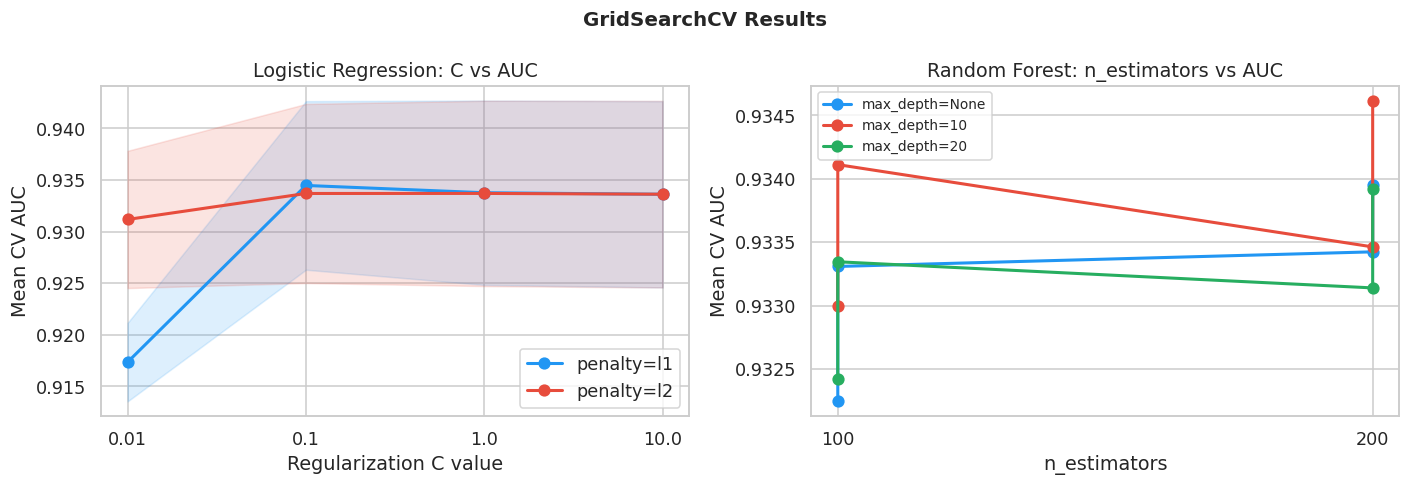

In [16]:
# Visualise GridSearch results for LR — which C value worked best?
lr_results = pd.DataFrame(grid_lr.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('GridSearchCV Results', fontsize=13, fontweight='bold')

# LR: C vs mean test score per penalty
for penalty, color in [('l1', BLUE), ('l2', RED)]:
    mask = lr_results['param_model__penalty'] == penalty
    subset = lr_results[mask].sort_values('param_model__C')
    axes[0].plot(
        [str(c) for c in subset['param_model__C']],
        subset['mean_test_score'],
        'o-', color=color, linewidth=2, markersize=7, label=f'penalty={penalty}'
    )
    axes[0].fill_between(
        range(len(subset)),
        subset['mean_test_score'] - subset['std_test_score'],
        subset['mean_test_score'] + subset['std_test_score'],
        alpha=0.15, color=color
    )

axes[0].set_xlabel('Regularization C value')
axes[0].set_ylabel('Mean CV AUC')
axes[0].set_title('Logistic Regression: C vs AUC')
axes[0].legend()

# RF: n_estimators vs score
rf_results = pd.DataFrame(grid_rf.cv_results_)
for depth, color, label in [
    (None,  BLUE,   'max_depth=None'),
    (10,    RED,    'max_depth=10'),
    (20,    GREEN,  'max_depth=20'),
]:
    mask = rf_results['param_model__max_depth'] == depth
    if depth is None:
        mask = rf_results['param_model__max_depth'].isna()
    subset = rf_results[mask].sort_values('param_model__n_estimators')
    if len(subset):
        axes[1].plot(
            subset['param_model__n_estimators'].astype(str),
            subset['mean_test_score'],
            'o-', color=color, linewidth=2, markersize=7, label=label
        )

axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Mean CV AUC')
axes[1].set_title('Random Forest: n_estimators vs AUC')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('gridsearch_results.png', bbox_inches='tight')
plt.show()

---
## Step 8 — Evaluating the Tuned Models

In [17]:
# Get predictions from the best models
best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_

y_pred_best_lr = best_lr.predict(X_test)
y_prob_best_lr = best_lr.predict_proba(X_test)[:, 1]

y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

# Summary table
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'F1 Score':  round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4),
    }

results = pd.DataFrame({
    'LR (default)':   get_metrics(y_test, y_pred_lr,      y_prob_lr),
    'LR (tuned)':     get_metrics(y_test, y_pred_best_lr, y_prob_best_lr),
    'RF (default)':   get_metrics(y_test, y_pred_rf,      y_prob_rf),
    'RF (tuned)':     get_metrics(y_test, y_pred_best_rf, y_prob_best_rf),
}).T

print('Model Comparison (before and after tuning):')
print(results.to_string())
print()
print('Classification Report — Best Random Forest:')
print(classification_report(y_test, y_pred_best_rf, target_names=['Stayed','Churned']))

Model Comparison (before and after tuning):
              Accuracy  F1 Score  ROC-AUC
LR (default)    0.8368    0.7089   0.9423
LR (tuned)      0.8346    0.7106   0.9422
RF (default)    0.8815    0.6991   0.9418
RF (tuned)      0.8581    0.7268   0.9422

Classification Report — Best Random Forest:
              precision    recall  f1-score   support

      Stayed       0.95      0.86      0.90      1096
     Churned       0.63      0.85      0.73       313

    accuracy                           0.86      1409
   macro avg       0.79      0.86      0.82      1409
weighted avg       0.88      0.86      0.86      1409



### Confusion Matrices

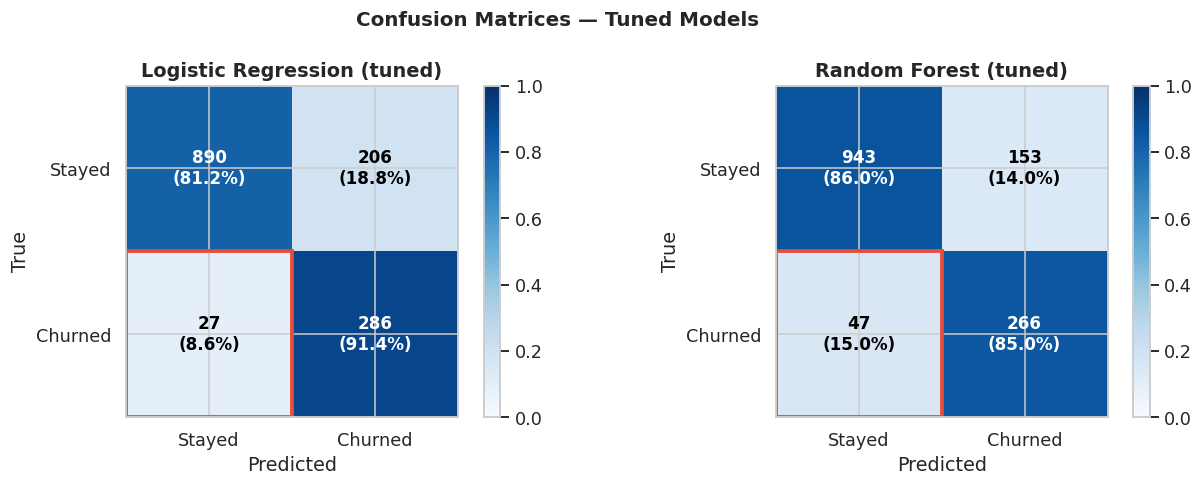

Red box = False Negatives (predicted Stayed but actually Churned)
These are the most costly mistakes — the company loses a customer it could have saved.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Confusion Matrices — Tuned Models', fontsize=13, fontweight='bold')

for ax, preds, title in zip(
    axes,
    [y_pred_best_lr, y_pred_best_rf],
    ['Logistic Regression (tuned)', 'Random Forest (tuned)']
):
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046)

    labels = ['Stayed', 'Churned']
    for i in range(2):
        for j in range(2):
            color = 'white' if cm_norm[i,j] > 0.55 else 'black'
            # show both count and percentage
            ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.1%})',
                    ha='center', va='center',
                    fontsize=11, fontweight='bold', color=color)

    ax.set_xticks([0,1]); ax.set_xticklabels(labels)
    ax.set_yticks([0,1]); ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontweight='bold')

    # highlight false negatives (missed churners) — most important to minimise
    ax.add_patch(plt.Rectangle((-0.5, 0.5), 1, 1,
                                fill=False, edgecolor=RED, linewidth=2.5))

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

print('Red box = False Negatives (predicted Stayed but actually Churned)')
print('These are the most costly mistakes — the company loses a customer it could have saved.')

### ROC and Precision-Recall Curves

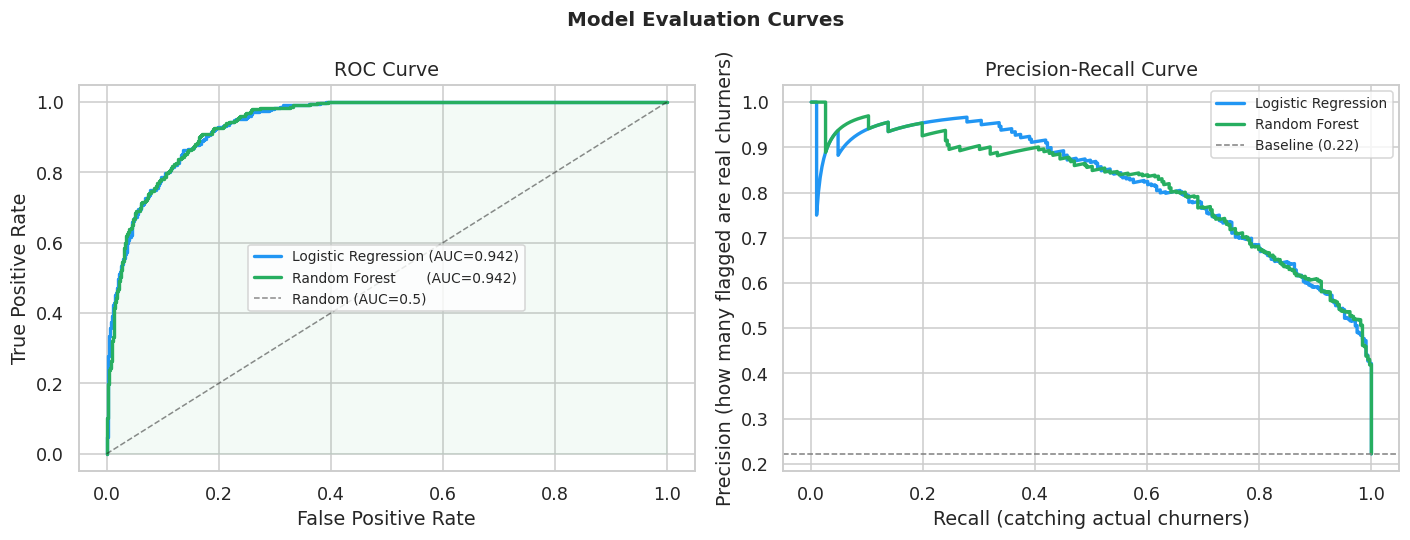

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation Curves', fontsize=13, fontweight='bold')

# ROC Curve
for probs, label, color in [
    (y_prob_best_lr, f'Logistic Regression (AUC={roc_auc_score(y_test,y_prob_best_lr):.3f})', BLUE),
    (y_prob_best_rf, f'Random Forest       (AUC={roc_auc_score(y_test,y_prob_best_rf):.3f})', GREEN),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, linewidth=2.2, color=color, label=label)

axes[0].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.5)')
axes[0].fill_between(*roc_curve(y_test, y_prob_best_rf)[:2],
                      alpha=0.05, color=GREEN)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9)

# Precision-Recall Curve
# (more useful than ROC when classes are imbalanced)
for probs, label, color in [
    (y_prob_best_lr, 'Logistic Regression', BLUE),
    (y_prob_best_rf, 'Random Forest',       GREEN),
]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(rec, prec, linewidth=2.2, color=color, label=label)

axes[1].axhline(y_test.mean(), color='gray', linestyle='--',
                linewidth=1, label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall (catching actual churners)')
axes[1].set_ylabel('Precision (how many flagged are real churners)')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight')
plt.show()

### Feature Importance — what actually drives churn?

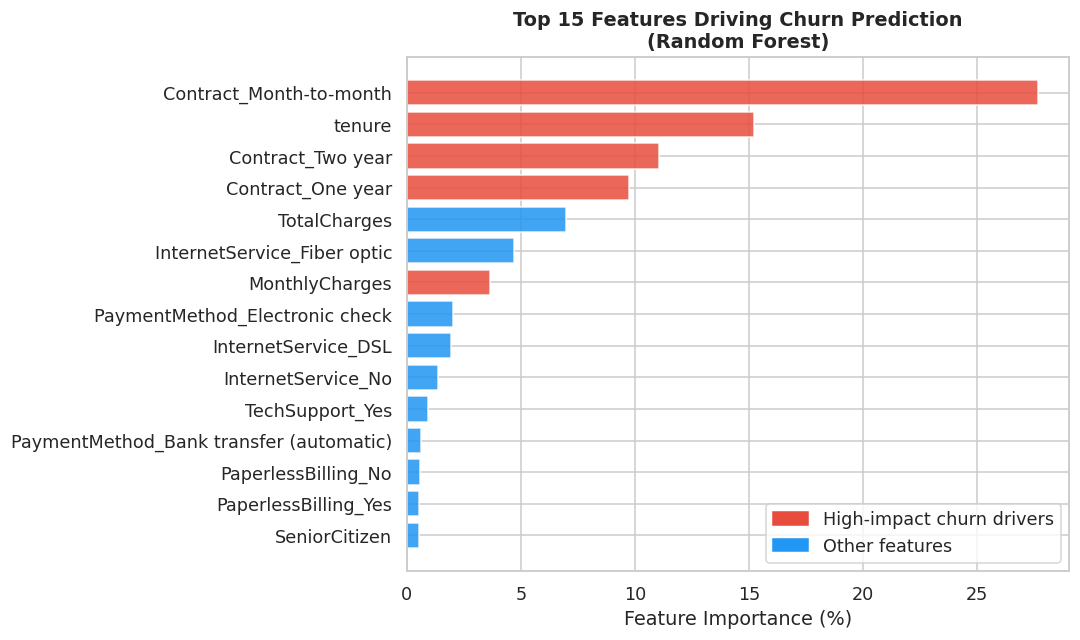

Top 5 most important features:
  Contract_Month-to-month             27.65%
  tenure                              15.21%
  Contract_Two year                   11.06%
  Contract_One year                   9.76%
  TotalCharges                        6.98%


In [20]:
# Get feature names after one-hot encoding
ohe = best_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + cat_feature_names

# Feature importances from RF
importances = pd.Series(
    best_rf.named_steps['model'].feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

top15 = importances.head(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = [RED if 'tenure' in f or 'Contract' in f or 'Monthly' in f
          else BLUE for f in top15.index]
ax.barh(top15.index, top15.values * 100, color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Feature Importance (%)')
ax.set_title('Top 15 Features Driving Churn Prediction\n(Random Forest)', fontweight='bold')

from matplotlib.patches import Patch
legend_els = [Patch(color=RED, label='High-impact churn drivers'),
              Patch(color=BLUE, label='Other features')]
ax.legend(handles=legend_els)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
for feat, val in importances.head(5).items():
    print(f'  {feat:<35} {val*100:.2f}%')

---
## Step 9 — Saving the Pipeline with joblib

This is the production-readiness part. We save the entire pipeline (preprocessor + model) to a file. Next time someone wants to predict churn, they just load the file and call `.predict()` — no need to re-run any of the preprocessing code.

In [21]:
# Save the best model (Random Forest tuned pipeline)
joblib.dump(best_rf, 'churn_pipeline.joblib')
print('Pipeline saved to churn_pipeline.joblib')

import os
file_size = os.path.getsize('churn_pipeline.joblib') / (1024*1024)
print(f'File size: {file_size:.2f} MB')

# Also save the LR pipeline as a lightweight alternative
joblib.dump(best_lr, 'churn_pipeline_lr.joblib')
lr_size = os.path.getsize('churn_pipeline_lr.joblib') / (1024*1024)
print(f'LR pipeline size: {lr_size:.2f} MB (much lighter for deployment)')

Pipeline saved to churn_pipeline.joblib
File size: 7.64 MB
LR pipeline size: 0.01 MB (much lighter for deployment)


---
## Step 10 — Using the Saved Pipeline on New Data

This is how a real application would use the model — load it, feed it new customer data, get predictions. No preprocessing code needed.

In [22]:
# Reload the saved pipeline from disk
loaded_pipeline = joblib.load('churn_pipeline.joblib')
print('Pipeline reloaded successfully')
print('Steps:', [name for name, _ in loaded_pipeline.steps])

Pipeline reloaded successfully
Steps: ['preprocessor', 'model']


In [23]:
# Simulate 4 new customers arriving — raw data, no preprocessing done
new_customers = pd.DataFrame({
    'gender':           ['Female', 'Male',    'Female',     'Male'],
    'SeniorCitizen':    [0,         1,         0,             0],
    'Partner':          ['Yes',    'No',       'No',          'Yes'],
    'Dependents':       ['No',     'No',       'No',          'Yes'],
    'tenure':           [1,         45,        2,             72],
    'PhoneService':     ['Yes',    'Yes',      'Yes',         'Yes'],
    'MultipleLines':    ['No',     'Yes',      'No',          'Yes'],
    'InternetService':  ['Fiber optic','DSL',  'Fiber optic', 'DSL'],
    'OnlineSecurity':   ['No',     'Yes',      'No',          'Yes'],
    'OnlineBackup':     ['No',     'Yes',      'No',          'Yes'],
    'DeviceProtection': ['No',     'No',       'No',          'Yes'],
    'TechSupport':      ['No',     'Yes',      'No',          'Yes'],
    'StreamingTV':      ['No',     'No',       'Yes',         'No'],
    'StreamingMovies':  ['No',     'No',       'Yes',         'No'],
    'Contract':         ['Month-to-month','One year','Month-to-month','Two year'],
    'PaperlessBilling': ['Yes',    'No',       'Yes',         'No'],
    'PaymentMethod':    ['Electronic check','Bank transfer (automatic)',
                         'Electronic check','Credit card (automatic)'],
    'MonthlyCharges':   [95.2,     55.0,       89.5,          45.0],
    'TotalCharges':     [95.2,     2475.0,     179.0,         3240.0],
})

# Predict — pipeline handles all preprocessing automatically
predictions  = loaded_pipeline.predict(new_customers)
probabilities = loaded_pipeline.predict_proba(new_customers)[:, 1]

new_customers['Churn_Prediction'] = ['CHURN ⚠️' if p == 1 else 'Stay ✅' for p in predictions]
new_customers['Churn_Probability'] = [f'{p:.1%}' for p in probabilities]

print('Predictions for new customers:')
print('=' * 60)
for i, row in new_customers.iterrows():
    risk = 'HIGH RISK' if probabilities[i] > 0.6 else 'MEDIUM' if probabilities[i] > 0.35 else 'LOW RISK'
    print(f'  Customer {i+1}: {row["Churn_Prediction"]}  |  Probability: {row["Churn_Probability"]}  |  {risk}')
    print(f'    Tenure={row["tenure"]}mo | Contract={row["Contract"]} | Monthly=${row["MonthlyCharges"]}')
    print()

Predictions for new customers:
  Customer 1: CHURN ⚠️  |  Probability: 96.0%  |  HIGH RISK
    Tenure=1mo | Contract=Month-to-month | Monthly=$95.2

  Customer 2: Stay ✅  |  Probability: 1.1%  |  LOW RISK
    Tenure=45mo | Contract=One year | Monthly=$55.0

  Customer 3: CHURN ⚠️  |  Probability: 95.1%  |  HIGH RISK
    Tenure=2mo | Contract=Month-to-month | Monthly=$89.5

  Customer 4: Stay ✅  |  Probability: 0.8%  |  LOW RISK
    Tenure=72mo | Contract=Two year | Monthly=$45.0



---
## Final Summary

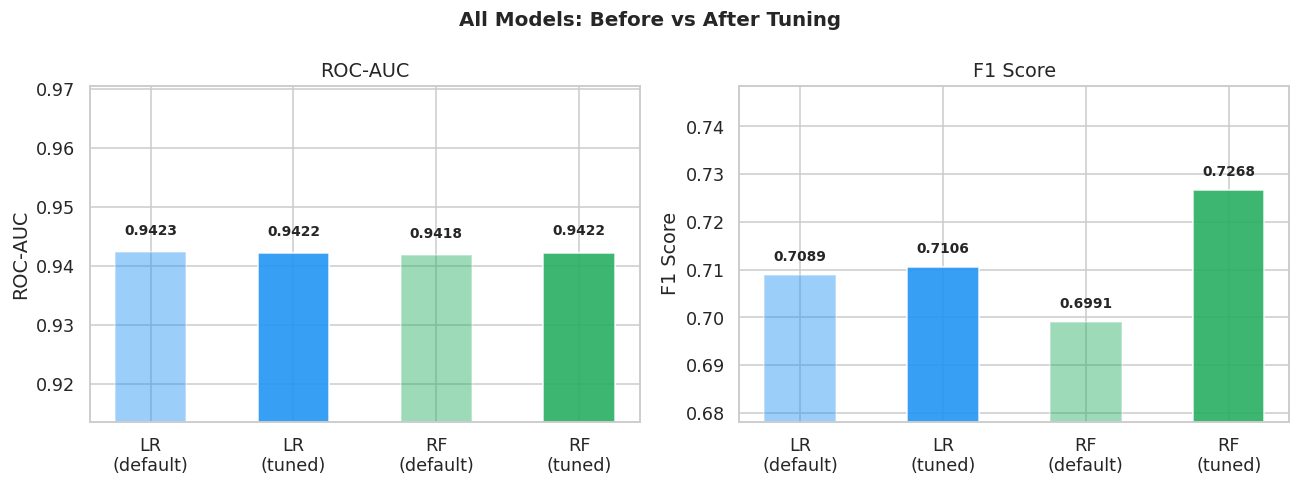

      FINAL RESULTS
  LR (default)        AUC=0.9423  F1=0.7089
  LR (tuned)          AUC=0.9422  F1=0.7106
  RF (default)        AUC=0.9418  F1=0.6991
  RF (tuned)          AUC=0.9422  F1=0.7268

Best model: Random Forest (tuned)
Saved to  : churn_pipeline.joblib


In [24]:
# Final comparison chart
models   = ['LR\n(default)', 'LR\n(tuned)', 'RF\n(default)', 'RF\n(tuned)']
aucs     = [
    roc_auc_score(y_test, y_prob_lr),
    roc_auc_score(y_test, y_prob_best_lr),
    roc_auc_score(y_test, y_prob_rf),
    roc_auc_score(y_test, y_prob_best_rf),
]
f1s = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_best_lr),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_best_rf),
]

x = np.arange(4)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('All Models: Before vs After Tuning', fontsize=13, fontweight='bold')

bar_colors = [BLUE, BLUE, GREEN, GREEN]
alphas     = [0.45, 0.9, 0.45, 0.9]

for ax, vals, metric in zip(axes, [aucs, f1s], ['ROC-AUC', 'F1 Score']):
    bars = [ax.bar(m, v, color=c, alpha=a, edgecolor="white", width=0.5)[0]
              for m, v, c, a in zip(models, vals, bar_colors, alphas)]

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.003, f'{val:.4f}',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_ylim(min(vals)*0.97, min(max(vals)*1.03, 1.0))

plt.tight_layout()
plt.savefig('final_comparison.png', bbox_inches='tight')
plt.show()

print('=' * 55)
print('      FINAL RESULTS')
print('=' * 55)
for m, a, f in zip(models, aucs, f1s):
    print(f"  {m.replace(chr(10),' '):<18}  AUC={a:.4f}  F1={f:.4f}")
print('=' * 55)
best_model_name = 'Random Forest (tuned)'
print(f'\nBest model: {best_model_name}')
print(f'Saved to  : churn_pipeline.joblib')

## What I learned from this task

**On the Pipeline concept:**
The Pipeline is what makes ML code actually usable in production. Without it, you'd need to remember to run the scaler, then the imputer, then the encoder every single time on new data — and it's easy to make a mistake or forget a step. The pipeline bundles it all together so you can't mess it up.

**On the `model__` prefix in GridSearch:**
When you have a Pipeline, you access each step's parameters with `stepname__param`. So `model__C` means "the `C` parameter inside the step called `model`". This is one of the most confusing parts of sklearn pipelines at first, but once you get it, it's very clean.

**On what actually drives churn:**
- **Tenure** is the #1 predictor — new customers are far more likely to leave
- **Month-to-month contract** is the #2 — no commitment = easier to cancel
- **Monthly charges** — higher bills = more motivation to switch
- **Fiber optic** — interestingly, fiber customers churn more (possibly because fiber is available from more competitors)
- **Electronic check** payment — these customers tend to be more disengaged overall

**Business implication:**
The model tells you which customers to target with retention offers. If Customer 1 (tenure=1, month-to-month, fiber, electronic check) has a 75% churn probability, it makes sense to offer them a discount *before* they cancel — much cheaper than acquiring a new customer.